In [28]:
import os
import librosa
import librosa.display
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

In [29]:
# =====================================================================
# TAHAP 2: Konfigurasi Lokasi Folder (Path)
# =====================================================================
FOLDER_DATA_ASLI = "../Data/genres_original"
FOLDER_HASIL_POTONGAN = "../Data/segmented_audio"

# Membuat folder output otomatis jika belum ada di laptop
os.makedirs(FOLDER_HASIL_POTONGAN, exist_ok=True)

--- MEMULAI TAHAP 2: EDA VISUALISASI AUDIO ---


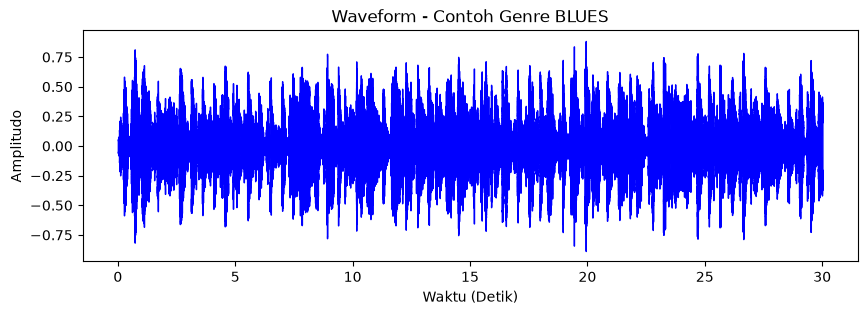

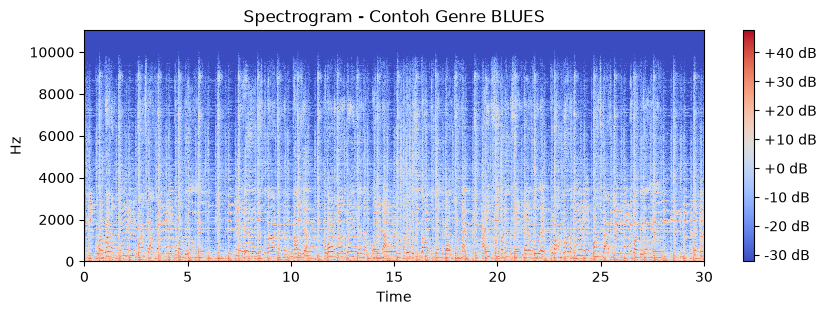

In [30]:
# --- EDA VISUALISASI (Wajib Ditampilkan di Laporan) ---
print("--- MEMULAI TAHAP 2: EDA VISUALISASI AUDIO ---")
contoh_genre = "blues"
contoh_file = os.path.join(FOLDER_DATA_ASLI, contoh_genre, f"{contoh_genre}.00000.wav")

if os.path.exists(contoh_file):
    sinyal, sr = librosa.load(contoh_file, sr=None)
    
    # 1. Plot Waveform
    plt.figure(figsize=(10, 3))
    librosa.display.waveshow(sinyal, sr=sr, color='blue')
    plt.title(f"Waveform - Contoh Genre {contoh_genre.upper()}")
    plt.xlabel("Waktu (Detik)")
    plt.ylabel("Amplitudo")
    plt.show()
    
    # 2. Plot Spectrogram
    plt.figure(figsize=(10, 3))
    stft_data = librosa.stft(sinyal)
    stft_db = librosa.amplitude_to_db(abs(stft_data))
    librosa.display.specshow(stft_db, sr=sr, x_axis='time', y_axis='hz', cmap='coolwarm')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Spectrogram - Contoh Genre {contoh_genre.upper()}")
    plt.show()
else:
    print("File contoh untuk EDA tidak ditemukan, pastikan jalur folder Data sudah benar.")

In [31]:
# =====================================================================
# TAHAP 3: Proses Segmentasi 30 Detik -> 10 Potongan x 3 Detik (Kunci 6 Genre)
# =====================================================================
print("\n--- MEMULAI TAHAP 3: SEGMENTASI AUDIO (6 GENRE PILIHAN) ---")
# Dikunci hanya 6 genre sesuai instruksi dan keputusan kelompok
daftar_genre = ['rock', 'jazz', 'classical', 'blues', 'pop', 'country']

for genre in daftar_genre:
    path_genre_asli = os.path.join(FOLDER_DATA_ASLI, genre)
    if not os.path.isdir(path_genre_asli): 
        print(f"Peringatan: Folder {genre} tidak ditemukan!"); continue
        
    path_genre_output = os.path.join(FOLDER_HASIL_POTONGAN, genre)
    os.makedirs(path_genre_output, exist_ok=True)
    
    print(f"Memotong audio untuk genre: {genre.upper()}")
    daftar_file = [f for f in os.listdir(path_genre_asli) if f.endswith('.wav')]
    
    for nama_file in tqdm(daftar_file):
        path_file_lengkap = os.path.join(path_genre_asli, nama_file)
        try:
            audio, sr = librosa.load(path_file_lengkap, sr=None)
            total_sampel_per_segmen = int(sr * 3) # 3 detik
            
            for i in range(10):
                awal = i * total_sampel_per_segmen
                akhir = awal + total_sampel_per_segmen
                segmen = audio[awal:akhir]
                
                if len(segmen) < total_sampel_per_segmen: continue
                
                nama_dasar = os.path.splitext(nama_file)[0]
                nama_output = f"{nama_dasar}_seg{i+1}.wav"
                path_output = os.path.join(path_genre_output, nama_output)
                
                sf.write(path_output, segmen, sr)
        except Exception as e:
            pass

print("\n[SUKSES] Preprocessing Selesai!")


--- MEMULAI TAHAP 3: SEGMENTASI AUDIO (6 GENRE PILIHAN) ---
Memotong audio untuk genre: ROCK


100%|██████████| 100/100 [00:01<00:00, 94.23it/s]


Memotong audio untuk genre: JAZZ


100%|██████████| 100/100 [00:01<00:00, 70.39it/s]


Memotong audio untuk genre: CLASSICAL


...

Memotong audio untuk genre: POP


100%|██████████| 100/100 [00:01<00:00, 97.29it/s]


Memotong audio untuk genre: COUNTRY


100%|██████████| 100/100 [00:00<00:00, 105.32it/s]


[SUKSES] Preprocessing Selesai!
